In [8]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [9]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Chuẩn hóa giá trị pixel pixel về khoảng [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Danh sách tên các lớp trong CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1771s 10us/step


In [11]:
# Mô hình CNN cơ bản
model = models.Sequential()

model.add(layers.Input(shape=(32, 32, 3)))

# Tầng CNN thứ 1: Lọc đặc trưng ban đầu
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Tầng CNN thứ 2: Học các đặc trưng phức tạp hơn
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Tầng CNN thứ 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten và phân loại
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
  56/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1200 - loss: 2.3047

I0000 00:00:1783916356.539720     218 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4343 - loss: 1.5504 - val_accuracy: 0.5329 - val_loss: 1.3221
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5797 - loss: 1.1845 - val_accuracy: 0.5995 - val_loss: 1.1266
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6352 - loss: 1.0399 - val_accuracy: 0.6352 - val_loss: 1.0346
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6728 - loss: 0.9335 - val_accuracy: 0.6532 - val_loss: 0.9993
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6990 - loss: 0.8594 - val_accuracy: 0.6738 - val_loss: 0.9596
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7206 - loss: 0.8006 - val_accuracy: 0.6921 - val_loss: 0.8958
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7355 - loss: 0.7547 - val_accuracy: 0.7025 - val_loss: 0.8739
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7522 - loss: 0.7098 - val_accura

In [13]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm thử (Test Accuracy): {test_acc*100:.2f}%')

313/313 - 1s - 2ms/step - accuracy: 0.7052 - loss: 0.8600

Độ chính xác trên tập kiểm thử (Test Accuracy): 70.52%


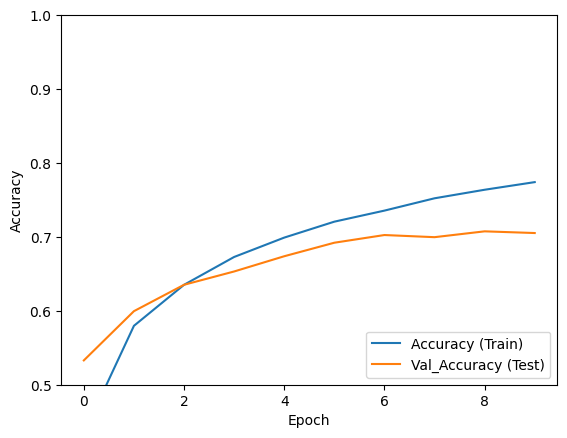

In [14]:
plt.plot(history.history['accuracy'], label='Accuracy (Train)')
plt.plot(history.history['val_accuracy'], label = 'Val_Accuracy (Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

In [46]:
model = models.Sequential()

# 1. Định nghĩa đầu vào
model.add(layers.Input(shape=(32, 32, 3)))

# 2. Tăng cường dữ liệu
model.add(layers.RandomFlip("horizontal"))
model.add(layers.RandomRotation(0.1))

# --- KHỐI CNN 1 (Nâng lên 64 Filters, Giảm Dropout) ---
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2)) # Giữ mức thấp ở tầng đầu

# --- KHỐI CNN 2 (Nâng lên 128 Filters) ---
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# --- KHỐI CNN 3 (Nâng lên 256 Filters để học sâu) ---
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))

# --- TẦNG PHÂN LOẠI (Dense 512 để xử lý lượng đặc trưng lớn hơn) ---
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,253,834 (12.41 MB)

 Trainable params: 3,251,018 (12.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
import tensorflow as tf

callbacks_list = [
    # Tự động giảm Learning Rate khi val_loss đứng yên trong 3 epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=5,
        verbose=1, 
        min_lr=1e-6
    ),
    
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=12,
        restore_best_weights=True, 
        verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_images, 
    train_labels, 
    epochs=80,  
    validation_data=(test_images, test_labels),
    callbacks=callbacks_list  
)

Epoch 1/80


E0000 00:00:1783925601.955699      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_7_1/dropout_17_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.4437 - loss: 1.6303 - val_accuracy: 0.5832 - val_loss: 1.1715 - learning_rate: 0.0010
Epoch 2/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6078 - loss: 1.1236 - val_accuracy: 0.6582 - val_loss: 0.9793 - learning_rate: 0.0010
Epoch 3/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6643 - loss: 0.9724 - val_accuracy: 0.7158 - val_loss: 0.8199 - learning_rate: 0.0010
Epoch 4/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.7017 - loss: 0.8674 - val_accuracy: 0.7405 - val_loss: 0.7668 - learning_rate: 0.0010
Epoch 5/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7249 - loss: 0.8013 - val_accuracy: 0.7706 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 6/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7416 - loss: 0.7562 - val_accuracy: 0.7932 - val_loss: 0.6029 - learning_rate: 0.0010
Epoch 7/80
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7559 

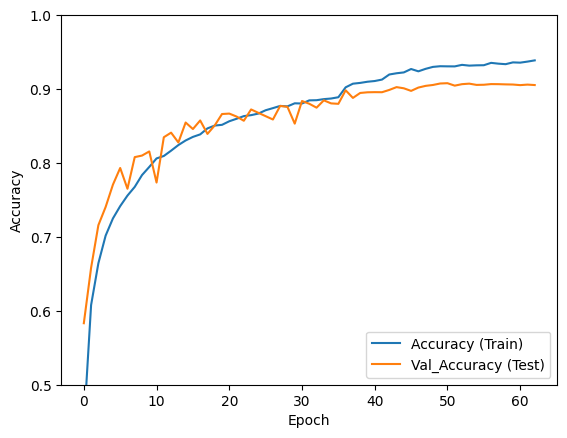

In [45]:
plt.plot(history.history['accuracy'], label='Accuracy (Train)')
plt.plot(history.history['val_accuracy'], label = 'Val_Accuracy (Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

🔄 Đang nạp mô hình từ bộ nhớ Kaggle...
✅ Nạp mô hình thành công!

🚀 Đang phân tích đồng loạt 10 hình ảnh...
-----------------------------------------------------------------
📸 [1] File: horse.jpg       -> Model đoán: HORSE (100.0%)
📸 [2] File: automobile.jpg  -> Model đoán: AUTOMOBILE (100.0%)
📸 [3] File: deer.jpg        -> Model đoán: DEER (98.9%)
📸 [4] File: cat.jpg         -> Model đoán: CAT (98.9%)
📸 [5] File: dog.jpg         -> Model đoán: DOG (100.0%)
📸 [6] File: bird.jpg        -> Model đoán: BIRD (98.0%)
📸 [7] File: trcuk.jpg       -> Model đoán: TRUCK (100.0%)
📸 [8] File: ship.jpg        -> Model đoán: SHIP (100.0%)
📸 [9] File: Air-New-Zealand-Boeing-747-400.jpg -> Model đoán: AIRPLANE (100.0%)
📸 [10] File: frog.jpg        -> Model đoán: FROG (100.0%)
-----------------------------------------------------------------
📊 Đã hoàn thành xử lý dự đoán và xuất biểu đồ lưới thành công!
-----------------------------------------------------------------


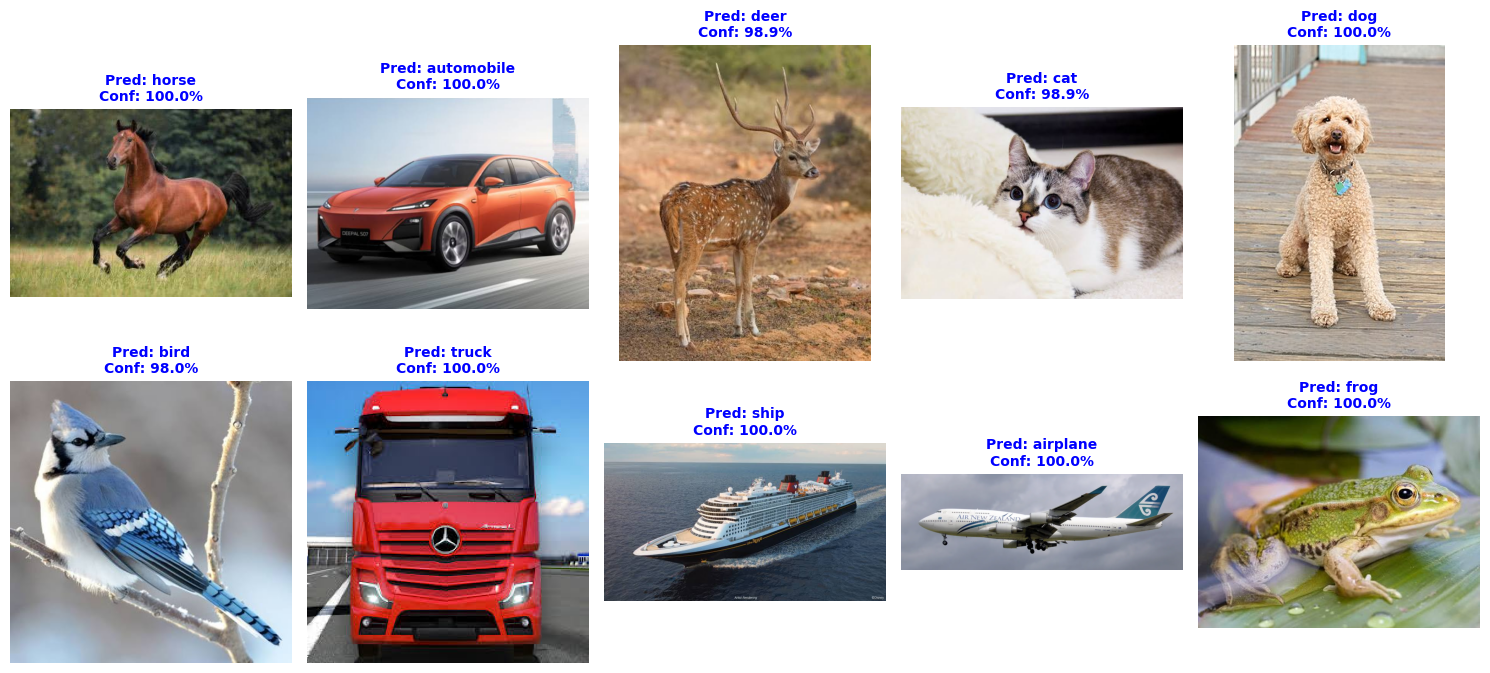

In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# 1. Định nghĩa 10 nhãn của CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. CẤU HÌNH ĐƯỜNG DẪN TRÊN KAGGLE
MODEL_PATH = "/kaggle/working/my_cifar10_model.keras"
IMAGE_DIR = "/kaggle/input/datasets/tuanvu2525/test-images/image"  

if os.path.exists(MODEL_PATH) and os.path.exists(IMAGE_DIR):
    print("🔄 Đang nạp mô hình từ bộ nhớ Kaggle...")
    saved_model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Nạp mô hình thành công!")

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(valid_extensions)][:10]

    total_images = len(image_files)

    cols = 5
    rows = int(np.ceil(total_images / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    
    if total_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    print(f"\n🚀 Đang phân tích đồng loạt {total_images} hình ảnh...")
    print("-" * 65)

    for i, file_name in enumerate(image_files):
        img_path = os.path.join(IMAGE_DIR, file_name)
        
        # Đọc ảnh và xử lý chuẩn hóa kích thước 32x32
        img = Image.open(img_path).convert('RGB')
        img_resized = img.resize((32, 32))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Mô hình dự đoán
        predictions = saved_model.predict(img_array, verbose=0)
        probabilities = tf.nn.softmax(predictions[0]).numpy()
        
        class_id = np.argmax(probabilities)
        pred_label = class_names[class_id]
        confidence = probabilities[class_id] * 100
        
        # In kết quả dự đoán ra console (Không còn cột Nhãn gốc -> ĐÚNG/SAI)
        print(f"📸 [{i+1}] File: {file_name:<15} -> Model đoán: {pred_label.upper()} ({confidence:.1f}%)")

        # Hiển thị lên biểu đồ lưới
        axes[i].imshow(img)
        axes[i].axis('off')
        
        title_text = f"Pred: {pred_label}\nConf: {confidence:.1f}%"
        axes[i].set_title(title_text, color='blue', fontsize=10, fontweight='bold')

    # Tắt các khung vẽ thừa nếu số lượng ảnh không chia hết cho 5
    for j in range(total_images, len(axes)):
        axes[j].axis('off')

    print("-" * 65)
    print("📊 Đã hoàn thành xử lý dự đoán và xuất biểu đồ lưới thành công!")
    print("-" * 65)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Vui lòng kiểm tra lại đường dẫn MODEL_PATH hoặc thư mục IMAGE_DIR của bạn!")